# Phân tích Cơ cấu Lợi nhuận gộp theo Nguồn Đơn hàng (2013-2022)

## Bước 1: Thu thập & Liên kết Dữ liệu
Trích xuất và liên kết thông tin từ `order_items.csv`, `products.csv`, và `orders.csv`.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Tải dữ liệu
order_items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')
orders = pd.read_csv('orders.csv')

print("Đã tải thành công 3 bảng dữ liệu!")

Đã tải thành công 3 bảng dữ liệu!


## Bước 2: Nối bảng & Trích xuất Năm
Thực hiện LEFT JOIN `order_items` với `products` (qua `product_id`), sau đó LEFT JOIN với `orders` (qua `order_id`).

In [17]:
# Join 1: order_items LEFT JOIN products
df = order_items.merge(products[['product_id', 'cogs', 'price']], on='product_id', how='left')

# Join 2: LEFT JOIN với orders
df = df.merge(orders[['order_id', 'order_source', 'order_date']], on='order_id', how='left')

# Trích xuất trường Year từ order_date
df['order_date'] = pd.to_datetime(df['order_date'])
df['Year'] = df['order_date'].dt.year

df[['order_id', 'product_id', 'cogs', 'price', 'order_source', 'Year']].head()

,order_id,product_id,cogs,price,order_source,Year
0,1,2400,1053.798008,1109.261061,paid_search,2012
1,2,609,8987.704231,10426.571034,paid_search,2012
2,3,396,10091.012256,11028.428695,direct,2012
3,4,635,9205.430478,10745.220588,referral,2012
4,6,1935,1048.696357,1609.911509,email_campaign,2012


## Bước 3: Áp dụng Ràng buộc (Checklist)
- **Checklist 1:** Lọc bỏ rác dữ liệu bằng điều kiện `cogs < price` để tránh lợi nhuận âm vô lý.
- **Checklist 2:** Lọc trường `Year` chỉ lấy từ 2013 đến 2022 (chống rò rỉ dữ liệu năm 2023).

In [18]:
# Checklist 1: Lọc cogs < price
df = df[df['cogs'] < df['price']]

# Checklist 2: Lọc Year từ 2013 đến 2022
df = df[(df['Year'] >= 2013) & (df['Year'] <= 2022)]

print(f"Số lượng dòng dữ liệu sau khi lọc: {len(df):,}")

Số lượng dòng dữ liệu sau khi lọc: 677,662


## Bước 4: Công thức tính toán Lợi nhuận (Gross Profit) & Gom nhóm
`GP = (unit_price - cogs) * quantity`

Gom nhóm theo Năm và Kênh để tính tổng GP, sau đó tính tỷ lệ phần trăm.

In [19]:
# Tính Gross Profit (Triệu đồng)
df['Gross_Profit'] = ((df['unit_price'] - df['cogs']) * df['quantity']) / 1_000_000

# Gom nhóm theo Year và order_source
df_grouped = df.groupby(['Year', 'order_source'])['Gross_Profit'].sum().reset_index()

# Tính Tổng GP Toàn Công ty trong Năm
df_yearly = df.groupby('Year')['Gross_Profit'].sum().reset_index()
df_yearly.rename(columns={'Gross_Profit': 'Total_GP_Year'}, inplace=True)

# Kết hợp để tính tỷ lệ
df_final = df_grouped.merge(df_yearly, on='Year', how='left')
df_final['Ratio'] = (df_final['Gross_Profit'] / df_final['Total_GP_Year']) * 100

df_final.head()

,Year,order_source,Gross_Profit,Total_GP_Year,Ratio
0,2013,direct,16.016744,191.189314,8.377426
1,2013,email_campaign,24.543410,191.189314,12.837229
2,2013,organic_search,54.881106,191.189314,28.705112
3,2013,paid_search,40.166593,191.189314,21.008806
4,2013,referral,19.016308,191.189314,9.946324


## Bước 5: Trực quan hóa - Biểu đồ Stacked Bar Chart (Chuẩn NeurIPS)
Data Labels sử dụng số Absolute Profit rút gọn (vd: 1.25M, 850K). Tổng lợi nhuận từng năm hiển thị ở phía trên.

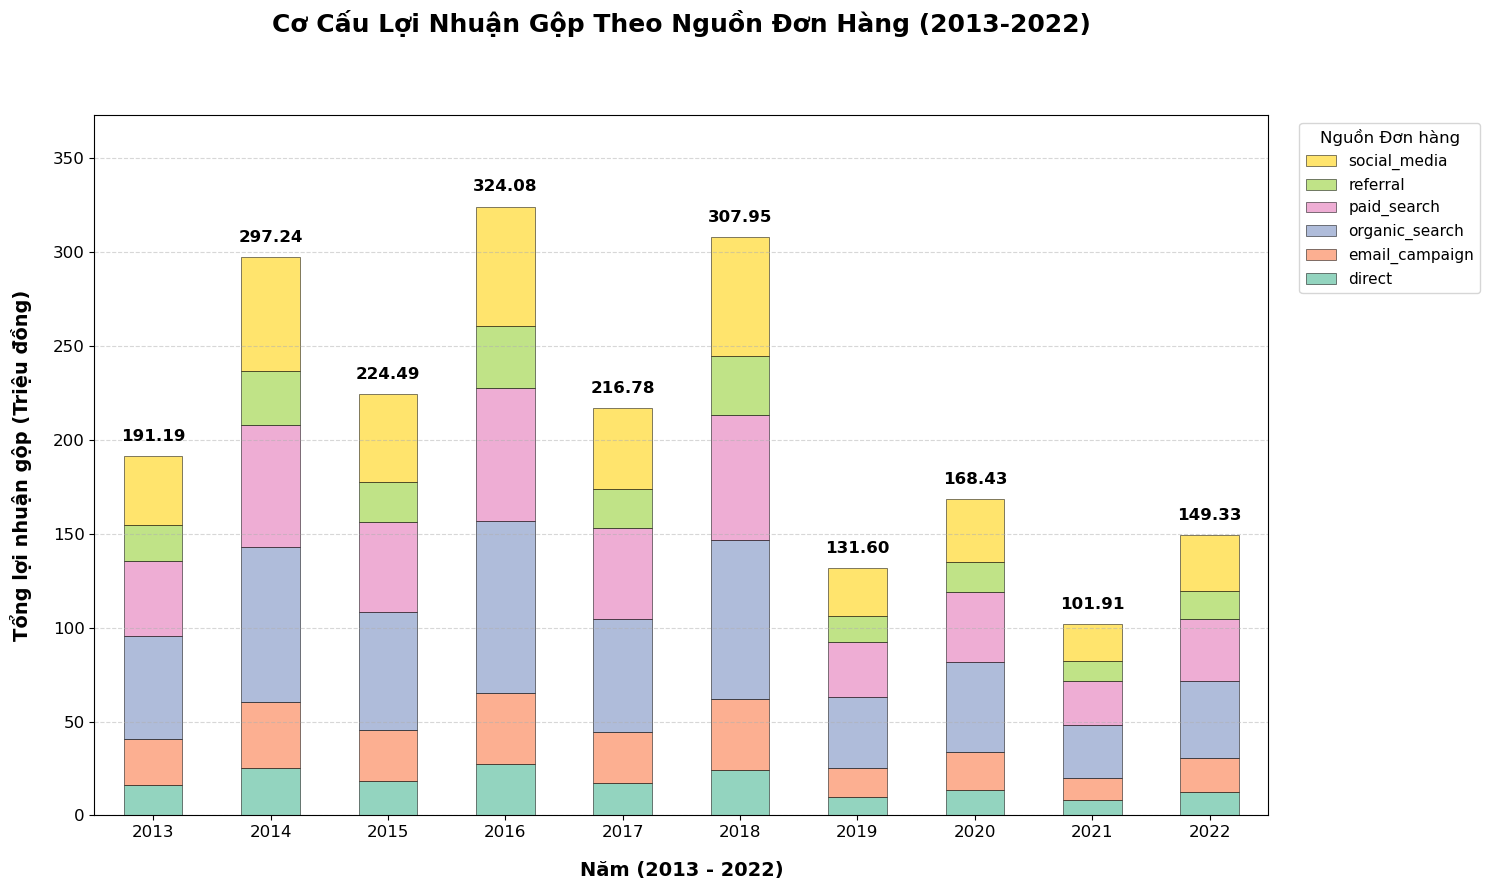

In [ ]:
# Pivot data cho đồ thị
pivot_ratio = df_final.pivot(index='Year', columns='order_source', values='Ratio').fillna(0)
pivot_abs = df_final.pivot(index='Year', columns='order_source', values='Gross_Profit').fillna(0)

# Đồng bộ màu sắc 6 kênh giống với Chart_Analysis.ipynb
sources = sorted(df_final['order_source'].dropna().unique())
colors = sns.color_palette("Set2", len(sources))
color_dict = dict(zip(sources, colors))

pivot_ratio = pivot_ratio[sources]
pivot_abs = pivot_abs[sources]
plot_colors = [color_dict[c] for c in pivot_ratio.columns]

# Hàm định dạng rút gọn số liệu
def format_currency(val):
    return f"{val:.2f}"

# Vẽ đồ thị
plt.style.use('default')
fig, ax = plt.subplots(figsize=(15, 9))

pivot_abs.plot(kind='bar', stacked=True, ax=ax, color=plot_colors, edgecolor='black', linewidth=0.5, alpha=0.7)


# Tổng lợi nhuận từng năm hiển thị ở phía trên
years = pivot_abs.index
max_total = df_yearly['Total_GP_Year'].max()
for i, year in enumerate(years):
    total_val = df_yearly[df_yearly['Year'] == year]['Total_GP_Year'].values[0]
    ax.text(i, total_val + (max_total * 0.02), f"{format_currency(total_val)}", ha='center', va='bottom', 
            fontsize=12, fontweight='bold', color='black')

# Cấu hình trục và tiêu đề
ax.set_title('Cơ Cấu Lợi Nhuận Gộp Theo Nguồn Đơn Hàng (2013-2022)', fontsize=18, fontweight='bold', pad=60)
ax.set_xlabel('Năm (2013 - 2022)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Tổng lợi nhuận gộp (Triệu đồng)', fontsize=14,  fontweight='bold', labelpad=15)
ax.set_ylim(0, max_total * 1.15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Kẻ đường ngang nét đứt mờ từ trục Y
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Cấu hình Legend
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels_leg[::-1], title='Nguồn lợi nhuận', 
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()